# 03 — TorchAO CPU INT8 PTQ

Notes:
- `backend='torchao_cpu_ptq'`, `device='cpu'`, `model_precision='int8'`.
- calib on `val` set


In [1]:
from pathlib import Path
import sys, os

# ---- Path setup (adjust if your repo layout differs) ----
PROJECT_ROOT = Path("..").resolve()
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

In [2]:
import pandas as pd

from config import ExperimentConfig, with_overrides
from runner import run_experiment
from utils import load_runs, flatten_runs
from plots import plot_tradeoff_scatter

pd.set_option("display.max_columns", 200)

In [3]:

base = ExperimentConfig(
    backend="torchao_cpu_ptq",
    device="cpu",
    batch_size=128,             # smaller batch for CPU
    model_precision="int8",     # model precision
    input_quant_bits=8,         
    seed=42,

    cpu_calib_split="val",
    cpu_calib_num_batches=1,
)

cfgs = [base]

# # calib sensitivity
# cfgs = [
#     with_overrides(base, cpu_calib_num_batches=5),
#     with_overrides(base, cpu_calib_num_batches=10),
#     with_overrides(base, cpu_calib_num_batches=25),
# ]

In [4]:
records = []
for cfg in cfgs:
    payload, _ = run_experiment(cfg, split="val", save_results_flag=True)
    records.append(payload)

for r in records:
    print(r["run_id"], r["status"], r["results"].get("top1_acc"))

/home/pf4636/code/resnet/quantized_resnets/.venv/lib/python3.12/site-packages/torchao/quantization/pt2e/quantizer/x86_inductor_quantizer.py:1325: UserWarning: The input of maxpool2d is not quantized, skip annotate maxpool2d with config QuantizationConfig(input_activation=QuantizationSpec(dtype=torch.uint8, observer_or_fake_quant_ctr=functools.partial(<class 'torchao.quantization.pt2e.observer.HistogramObserver'>, eps=0.000244140625){}, quant_min=0, quant_max=255, qscheme=torch.per_tensor_affine, ch_axis=None, is_dynamic=False), output_activation=QuantizationSpec(dtype=torch.uint8, observer_or_fake_quant_ctr=functools.partial(<class 'torchao.quantization.pt2e.observer.HistogramObserver'>, eps=0.000244140625){}, quant_min=0, quant_max=255, qscheme=torch.per_tensor_affine, ch_axis=None, is_dynamic=False), weight=QuantizationSpec(dtype=torch.int8, observer_or_fake_quant_ctr=functools.partial(<class 'torchao.quantization.pt2e.observer.PerChannelMinMaxObserver'>, eps=0.000244140625){}, quant

Evaluating on 390 batches...
  Batch [10/390] Top-1: 85.47% | Top-5: 95.62% | Infer: 776.88 ms/batch
  Batch [20/390] Top-1: 78.52% | Top-5: 93.16% | Infer: 756.68 ms/batch
  Batch [30/390] Top-1: 74.24% | Top-5: 92.06% | Infer: 747.31 ms/batch
  Batch [40/390] Top-1: 76.66% | Top-5: 92.68% | Infer: 746.10 ms/batch
  Batch [50/390] Top-1: 76.23% | Top-5: 92.23% | Infer: 747.27 ms/batch
  Batch [60/390] Top-1: 77.93% | Top-5: 92.85% | Infer: 743.66 ms/batch
  Batch [70/390] Top-1: 77.06% | Top-5: 92.79% | Infer: 743.24 ms/batch
  Batch [80/390] Top-1: 76.23% | Top-5: 92.95% | Infer: 750.07 ms/batch
  Batch [90/390] Top-1: 76.15% | Top-5: 92.99% | Infer: 752.88 ms/batch
  Batch [100/390] Top-1: 75.80% | Top-5: 93.20% | Infer: 754.58 ms/batch
  Batch [110/390] Top-1: 75.67% | Top-5: 93.31% | Infer: 754.88 ms/batch
  Batch [120/390] Top-1: 75.70% | Top-5: 93.38% | Infer: 756.35 ms/batch
  Batch [130/390] Top-1: 76.04% | Top-5: 93.46% | Infer: 758.15 ms/batch
  Batch [140/390] Top-1: 76.21%

In [7]:
runs = load_runs("./runs", status="ok")
rows = flatten_runs(runs)
df = pd.DataFrame(rows)

df_int8_cpu = df[
    (df["cfg.backend"] == "torchao_cpu_ptq")
    & (df["cfg.device"] == "cpu")
].copy()

df_int8_cpu[[
    "run_id",
    "cfg.backend",
    "cfg.device",
    "cfg.batch_size",
    "cfg.model_precision",
    "cfg.input_quant_bits",
    "cfg.cpu_calib_num_batches",
    "res.top1_acc",
    "res.top5_acc",
    "res.infer_ms_avg",
    "res.throughput_infer_sps",
    "res.total_samples",
]].sort_values(["cfg.cpu_calib_num_batches", "cfg.batch_size"])

,run_id,cfg.backend,cfg.device,cfg.batch_size,cfg.model_precision,cfg.input_quant_bits,cfg.cpu_calib_num_batches,res.top1_acc,res.top5_acc,res.infer_ms_avg,res.throughput_infer_sps,res.total_samples
7,resnet18_torchao_cpu_ptq_int8_in8b_cpu_bs128,torchao_cpu_ptq,cpu,128,int8,8,1,69.801683,89.100561,768.226987,166.617422,49920


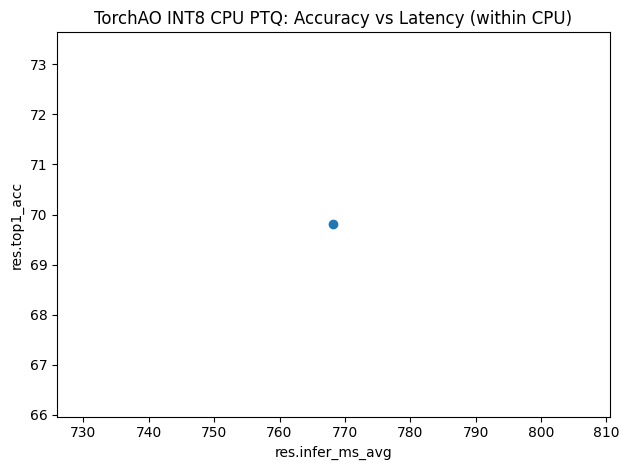

In [6]:
rows_int8_cpu = df_int8_cpu.to_dict(orient="records")
plot_tradeoff_scatter(
    rows_int8_cpu,
    x_key="res.infer_ms_avg",
    y_key="res.top1_acc",
    title="TorchAO INT8 CPU PTQ: Accuracy vs Latency (within CPU)",
    annotate=False,
)

